# Introduction to Computational Physics: Problem Set 7
Tutorial: Chun Ming Yip (Group 3)

Document created by: Vencel Szabó, Finn Zeumer

# Problem:
$$\frac{d^{2}T}{dx^{2}} = -\frac{q(x)}{k},\quad 0 < x < L,$$

where:

• $T (x)$ is the temperature profile in K,

• $k$ is the thermal conductivity in W m $^{−1}$ K $^{−1}$,

• $q(x)$ is the volumetric heat generation in W/m³.

Throughout this assignment we impose Dirichlet boundary conditions
$$T (0) = T (L) = 0$$


The domain is discretised using a uniform grid with spacing $h = L/(N + 1)$. 

Denote
the interior nodes by $x_i = ih (i = 1, . . . , N )$. The second derivative is approximated
by the central differencing formula. We would like to solve for the temperature.

# Libaries

In [14]:
!pip install astropy

  Using cached astropy-7.2.0-cp311-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (10 kB)
  Using cached pyerfa-2.0.1.5-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.7 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
Using cached astropy-7.2.0-cp311-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (9.8 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 8.2 MB/s eta 0:00:0000:0100:01
Using cached pyerfa-2.0.1.5-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (738 kB)
Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (807 kB)


In [3]:
from numpy.linalg import solve
import numpy as np
# import astropy.units as u
import matplotlib.pyplot as plt


# Exercice 1: Derive the matrix

We want to get to $A \cdot T(x) =b$,
which is translation from the continius ODE to an disscret ODE.

$A \in \text{matrix}(N \times N), \, b,T \in (N\times 1)$

We use 
$$
    \frac{d^2T}{dx^2}∣_{x_i} \approx 
    \frac{T_{i-1} − 2T_i + T_{i+1}}{h^2} =
    -\frac{q(x_i)}{k}
$$


We can reformulate this into:

$$
    -{T_{i-1} + 2T_i - T_{i+1}} =
    h^2 \, \underbrace{\frac{q(x_i)}{k}}_{f_i}  
$$

This is a system of equations we can solve. A couple of lines look like:

1.) $
    -T_{0} + 2T_1 - T_{2} = h^2\,f_1 \, , \qquad T_0 = 0 \, ,\\
    \Rightarrow \textcolor{red}{2}T_1 \textcolor{red}{-1} T_{2} = h^2\,f_1
    $

2.) $
    -T_{1} + 2T_2 - T_{3} = h^2\,f_2 \, ,\\
    \Rightarrow \textcolor{blue}{-1}T_1 \textcolor{blue}{2}T_2 \textcolor{blue}{-1} T_{3} = h^2\,f_1
    $

N.) $
    -T_{N-1} + 2T_N - T_{N+1} = h^2\,f_N \, , \qquad T_{N+1} = 0 \, ,\\
    \textcolor{green}{-1}T_{N-1} + \textcolor{green}{2}T_N = h^2\,f_N
    $

Thus $A$ looks like

$$
    A = 
    \begin{pmatrix}
        \textcolor{red}{2} & \textcolor{blue}{-1} & 0 & \cdots & 0 \\
        \textcolor{red}{-1} & \textcolor{blue}{2} & -1 & \cdots & 0 \\
        0 & \textcolor{blue}{-1} & 2 & \ddots & \vdots \\
        \vdots & \vdots & \ddots & \ddots & \textcolor{green}{-1} \\
        0 & 0 & \cdots & -1 & \textcolor{green}{2}
    \end{pmatrix}
$$

And $b$ will be 

$$
\mathbf{b} = \frac{h^2}{k} 
\begin{pmatrix}
    q(x_1) \\
    q(x_2) \\
    \vdots \\
    q(x_N)
\end{pmatrix}

=
h^2

\begin{pmatrix}
    f_1 \\
    f_2 \\
    \vdots \\
    f_N
\end{pmatrix}
$$

# Exercise 2: Implement Gauss-Jordan with partial pivoting.

In [4]:
# Defining test Matricis
simple_mat = np.array([[1, 2, 3], 
                       [4, -5, 6], 
                       [7, 8, 9]], dtype=float)

A_test = np.array([[2, 1, -1], 
                   [-3, -1, 2], 
                   [-2, 1, 2]], dtype=float)

b_test = np.array([8, -11, -3], dtype=float)

In [5]:
def gauss_jordan(A:np.ndarray, b:np.ndarray):
    '''
    Solves Ax = b for x using gauss-jordan.

    Params
    ______
    A : numpy.ndarray (N x N)
    b : numpy.ndarray (N x 1)
    
    Returns
    _______
    x : numpy.ndarray (N x 1)
    '''

    # Combine A and b to M. b will be transposed.
    n = len(b)
    M = np.hstack((A, b.reshape(-1,1)))

    # Actual Gauss-Jordan
    for i in range(n):
        # Find the index of the row with the largest absolute value in column i
        max_row = i + np.argmax(np.abs(M[i:,i]))

        # Swap current row i with max_row
        if max_row != i:
            M[[i, max_row]] = M[[max_row, i]]

        # Check for zero pivot
        if abs(M[i, i]) < 1e-12:
            raise ValueError("Matrix is (nearly) singular.")
        
        # Normalize by the diagonal elemetns M[i,i]
        pivot = M[i, i]
        M[i] = M[i] / pivot

        # Make other elements in column zero
        for k in range(n):
            # check if column is the correct one
            if k != i:
                factor = M[k,i]
                M[k] = M[k] - factor * M[i]

    # getting the solution
    x = M[:,-1]
    return x

In [6]:
# Testing the method
solution = gauss_jordan(simple_mat, b_test)
print("Solution:\nx =", solution)

Solution:
x = [-7.425       1.35        4.24166667]


# Exersice 3) Constant heat source ($q =$ const)

In [7]:
# Values for this exercise
q_0 = 1 #* u.W * u.m**-3
k = 1 #* u.W * u.m**-1 * u.K**-1

N_values = [10, 20, 50, 100]

L = 1 #* u.m

In [8]:
def build_system(N, L, k, q_0):
    h = L / (N + 1)
    
    # Build A (Tridiagonal)
    main_diag = 2 * np.ones(N)
    off_diag = -1 * np.ones(N - 1)
    A = np.diag(main_diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)
    
    # Build b
    # b_i = h^2 * q(x_i) / k. Since q is constant:
    b = (h**2 * q_0 / k) * np.ones(N)
    
    return A, b, h

In [9]:
def analytical_solution(x, L, k, q_0):
    return (q_0 / (2 * k)) * (L * x - x**2)

N     | Max Error       | Cond Num       
----------------------------------------
10    | 2.77556e-17   | 4.84e+01
20    | 5.55112e-17   | 1.78e+02
50    | 9.71445e-16   | 1.05e+03


100   | 1.11022e-15   | 4.13e+03


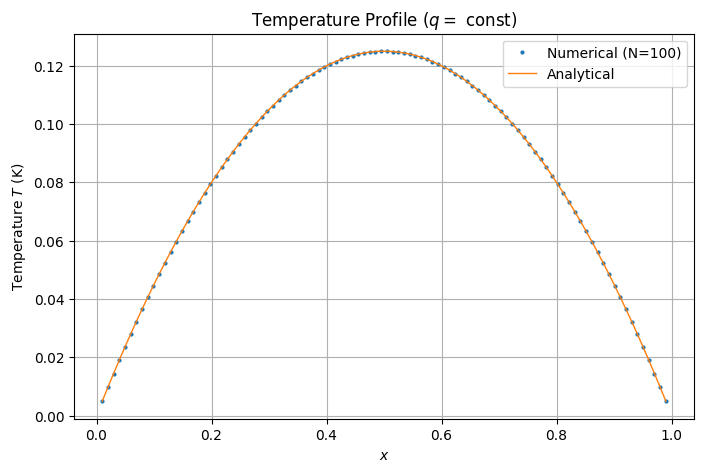

In [10]:
results = []

print(f"{'N':<5} | {'Max Error':<15} | {'Cond Num':<15}")
print("-" * 40)

for N in N_values:
    A, b, h = build_system(N, L, k, q_0)
    
    # Solve
    T_num = gauss_jordan(A, b)
    
    # Grid points
    x_grid = np.linspace(h, L-h, N)
    
    # Analytical
    T_ana = analytical_solution(x_grid, L, k, q_0)
    
    # Max Error
    max_error = np.max(np.abs(T_num - T_ana))
    
    # Condition Number
    cond_num = np.linalg.cond(A, p=2)
    
    print(f"{N:<5} | {max_error:.5e}   | {cond_num:.2e}")
    
    results.append((N, max_error, cond_num, x_grid, T_num, T_ana))

plt.figure(figsize=(8, 5))
for N, _, _, x_grid, T_num, T_ana in results:
    if N == 100: # Just plot N = 100
        plt.plot(x_grid, T_num, 'o', label='Numerical (N=100)', markersize=2)
        plt.plot(x_grid, T_ana, '-', label='Analytical', linewidth=1)

plt.title('Temperature Profile ($q = $ const)')
plt.xlabel('$x$')
plt.ylabel('Temperature $T$ (K)')
plt.legend()
plt.grid(True)
plt.show()

There is a trend between N, the max Error and the Conditional Number; when we increase the amout of Cells N, the max error gets bigger as well as the conditonal number. But we would expect otherwise for the error. Expection:

Gridsapcing decreses by:
+ $h \, \propto \, 1/N$

Condition Number ($\kappa$) should increas by:
+ $\kappa \, \propto \, N^2$

Max Error should decrease by:
+ $\epsilon \, \propto \, h^2 \propto 1/N^2$

An Explernation would be that the numerical solution and the analytical solution differ only by round-off error from floating-point arithmetic.

# Exersice 4) Variable heat source ($q = q(x)$) 

In [11]:
# Define Q functions
def q_sine(x):
    return q_0 * np.sin(np.pi * x / L)

def q_gauss(x):
    sigma = L / 8.0
    return q_0 * np.exp(-((x - L/2)**2) / (sigma**2))


In [16]:
# Analytical solutions
def T_ana_sine(x):
    return (q_0 * L**2) / (np.pi**2 * k) * np.sin(np.pi * x / L)

# This function is ai generated: (It doesn't work anyways lol)
from scipy.special import erf
def T_ana_gauss(x):
    sigma = L / 8.0
    
    # Helper variables
    alpha = (x - L/2) / sigma
    beta = -L / (2 * sigma)  # value at x=0
    
    # The general form from double integration
    term1 = -q_0 * sigma**2 / (2 * k) * (alpha * erf(alpha) + np.exp(-alpha**2) / np.sqrt(np.pi))
    
    # Constants from boundary conditions
    erfbeta = erf(beta)
    exp_beta = np.exp(-(L**2)/(4 * sigma**2))
    
    C1 = (q_0 * sigma * np.sqrt(np.pi) / (4 * k * L)) * (erf(L/(2*sigma)) - erfbeta)
    C2 = (q_0 * sigma**2 / (2 * k)) * ((-L/(2*sigma)) * erfbeta + exp_beta / np.sqrt(np.pi))
    
    return term1 + C1 * x + C2

N     | Err Sine        | Err Gauss      
----------------------------------------
10    | 6.84484e-04   | 9.63187e-02
20    | 1.88647e-04   | 1.03204e-01
50    | 3.20298e-05   | 1.07660e-01


100   | 8.16854e-06   | 1.09204e-01


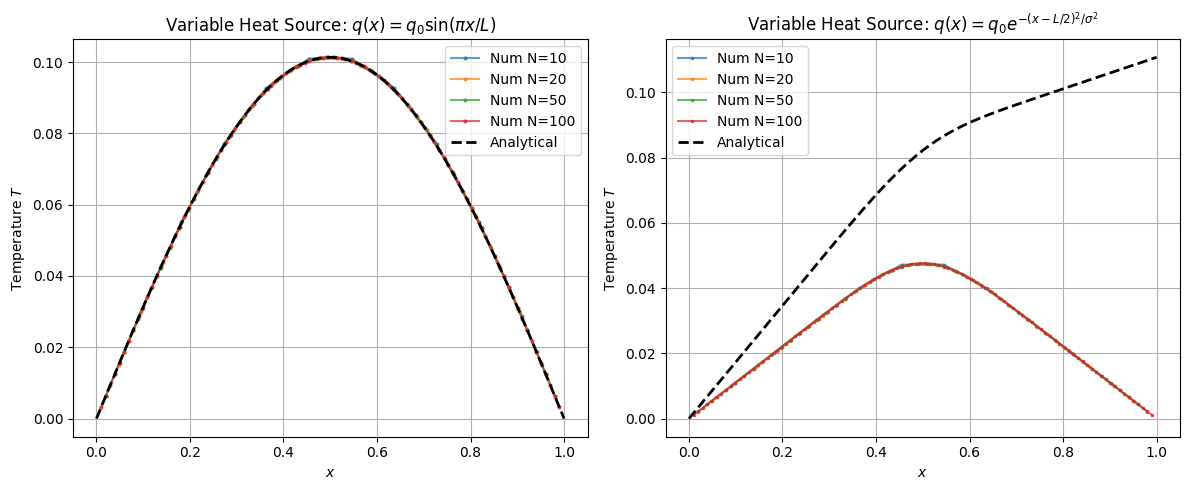

In [ ]:
print(f"{'N':<5} | {'Err Sine':<15} | {'Err Gauss':<15}")
print("-" * 40)

all_solutions = [] # Store to plot later

for N in N_values:
    h = L / (N + 1)
    x_grid = np.linspace(h, L - h, N)
    
    # Build System for Sine
    main_diag = 2 * np.ones(N)
    off_diag = -1 * np.ones(N - 1)
    A = np.diag(main_diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)
    
    # Sine Case
    b_sine = (h**2 / k) * q_sine(x_grid)
    T_sine_num = gauss_jordan(A, b_sine)
    T_sine_ana = T_ana_sine(x_grid)
    err_sine = np.max(np.abs(T_sine_num - T_sine_ana))
    
    # Gaussian Case
    b_gauss = (h**2 / k) * q_gauss(x_grid)
    T_gauss_num = gauss_jordan(A, b_gauss)
    # We do we fail here? What is wrong? T_ana_gauss is seems wrong definded.
    T_gauss_ana = T_ana_gauss(x_grid)
    err_gauss = np.max(np.abs(T_gauss_num - T_gauss_ana))

    # Store for plotting
    all_solutions.append((N, x_grid, T_sine_num, T_gauss_num))
    
    print(f"{N:<5} | {err_sine:.5e}   | {err_gauss:.5e}")

# Plotting
plt.figure(figsize=(12, 5))

# Plot 1: Sine Source
plt.subplot(1, 2, 1)

# Numerical
for N, x_grid, T_sine_num, _ in all_solutions:
    plt.plot(x_grid, T_sine_num, 'o-', label=f'Num N={N}', alpha=0.7, markersize=2)

# Analitical
x_fine = np.linspace(0, L, 200)
plt.plot(x_fine, T_ana_sine(x_fine), 'k--', linewidth=2, label='Analytical')

plt.title(r'Variable Heat Source: $q(x) = q_0 \sin(\pi x/L)$')
plt.xlabel('$x$')
plt.ylabel('Temperature $T$')
plt.legend()
plt.grid(True)

# Plot 2: Gaussian Source
plt.subplot(1, 2, 2)

# Numerical
for N, x_grid, _, T_gauss_num in all_solutions:
    plt.plot(x_grid, T_gauss_num, 's-', label=f'Num N={N}', alpha=0.7, markersize=2)

# Analitical
x_fine = np.linspace(0, L, 600)
plt.plot(x_fine, T_ana_gauss(x_fine), 'k--', linewidth=2, label='Analytical')


plt.title(r'Variable Heat Source: $q(x) = q_0 e^{-(x-L/2)^2/\sigma^2}$')
plt.xlabel('$x$')
plt.ylabel('Temperature $T$')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()